/tmp/ipykernel_7567/2929235924.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
/tmp/ipykernel_7567/2929235924.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  source2["Measurement Time"] = pd.to_datetime(source2["Measurement Time"])
/tmp/ipykernel_7567/2929235924.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  target["Measurement Time"] = pd.to_datetime(target["Measurement Time"])
/tmp/ipykernel_7567/2929235924.py:28: FutureWarning: 'H' is deprecated and will be removed in a future version

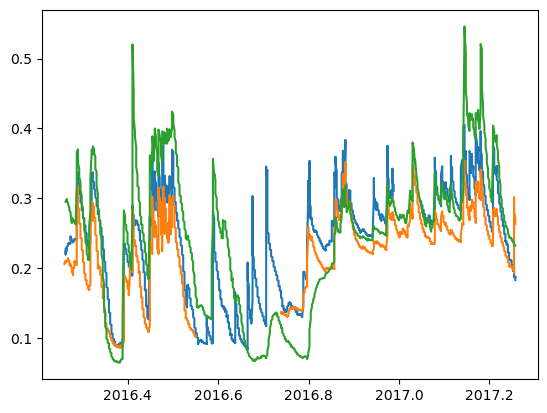

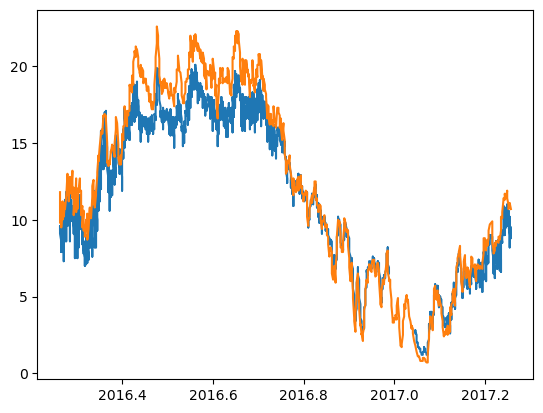

2915 729


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from pathlib import Path
import os
import sys
from pathlib import Path
home = Path.home()
subdir = home / "src" / "at-gpflow" / "experiments" / "soil-moisture" / "Wageningen" ## or whatever folder at-gpflow lives in
at_dir = home / "src" / "at-gpflow"


sys.path.append(str(at_dir))
sys.path.append(str(subdir))
BASE = str(subdir)

source = pd.read_csv(BASE+"/data/station_data/RM_SM_14_calibrated.csv")
source2 = pd.read_csv(BASE+"/data/station_data/RM_SM_02_calibrated.csv")
target = pd.read_csv(BASE+"/data/station_data/RM_SM_15_calibrated.csv")
source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
source2["Measurement Time"] = pd.to_datetime(source2["Measurement Time"])
target["Measurement Time"] = pd.to_datetime(target["Measurement Time"])

source.index = source["Measurement Time"]
source2.index = source2["Measurement Time"]
target.index = target["Measurement Time"]

source = source.resample("3H").last()
source2 = source2.resample("3H").last()
target = target.resample("12H").last()

source['decimal_year'] = source['Measurement Time'].dt.year + (source['Measurement Time'].dt.dayofyear - 1) / 365.25
source2['decimal_year'] = source2['Measurement Time'].dt.year + (source2['Measurement Time'].dt.dayofyear - 1) / 365.25
target['decimal_year'] = target['Measurement Time'].dt.year + (target['Measurement Time'].dt.dayofyear - 1) / 365.25
source.index = source["decimal_year"]
source2.index = source2["decimal_year"]
target.index = target["decimal_year"]


plt.plot(source.index, source["5 cm VWC [m3/m3]"])
plt.plot(source2.index, source2["5 cm VWC [m3/m3]"])
plt.plot(target.index, target["5 cm VWC [m3/m3]"])
plt.show()
plt.plot(source.index, source["5 cm Temp [oC]"])
plt.plot(target.index, target["5 cm Temp [oC]"])
plt.show()

print(len(source), len(target))

2017.2573579739903


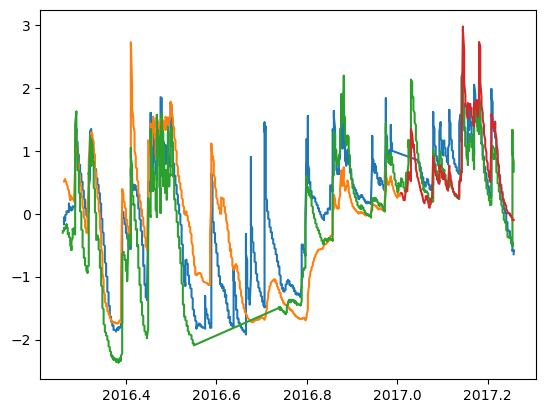

In [2]:
Ax = source.index.to_numpy().reshape(-1, 1)
Bx = target.index.to_numpy().reshape(-1, 1)
Cx = source2.index.to_numpy().reshape(-1, 1)

Ay_nans = source["5 cm VWC [m3/m3]"].to_numpy().reshape(-1, 1) 
Ay = Ay_nans[~np.isnan(Ay_nans)].reshape(-1, 1)
Ay = (Ay - Ay.mean()) / np.std(Ay)
Ax = Ax[~np.isnan(Ay_nans)].reshape(-1, 1)
Ay = (Ay - Ay.mean()) / np.std(Ay)
By_nans = target["5 cm VWC [m3/m3]"].to_numpy().reshape(-1, 1)
By = By_nans[~np.isnan(By_nans)].reshape(-1, 1)
By = (By - By.mean()) / np.std(By)
Bx = Bx[~np.isnan(By_nans)].reshape(-1, 1)

Xtest = Bx[int(len(Bx)*0.75):] 
ytest = By[int(len(By)*0.75):] 
Bx = Bx[:int(len(Bx)*0.75)] 
By = By[:int(len(By)*0.75)] 

Cy_nans = source2["5 cm VWC [m3/m3]"].to_numpy().reshape(-1, 1)
Cy = Cy_nans[~np.isnan(Cy_nans)].reshape(-1, 1)
Cy = (Cy - Cy.mean()) / np.std(Cy)
Cx = Cx[~np.isnan(Cy_nans)].reshape(-1, 1)

X = np.vstack((np.hstack((Ax, np.zeros_like(Ax))), np.hstack((Bx, np.ones_like(Bx)))))
y = np.vstack((np.hstack((Ay, np.zeros_like(Ay))), np.hstack((By, np.ones_like(By)))))
plt.plot(Ax, Ay)
plt.plot(Bx, By)
plt.plot(Cx, Cy)
plt.plot(Xtest, ytest)
print(np.max(X))

2026-08-25 15:13:51.274113: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-25 15:13:51.275610: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-25 15:13:51.301199: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-25 15:13:51.302461: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-25 15:13:51.845284: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

[[2.01626283e+03 0.00000000e+00]
 [2.01626283e+03 0.00000000e+00]
 [2.01626283e+03 0.00000000e+00]
 ...
 [2.01700274e+03 1.00000000e+00]
 [2.01700548e+03 1.00000000e+00]
 [2.01700548e+03 1.00000000e+00]]
[[2016.26283368]
 [2016.28313009]
 [2016.3034265 ]
 [2016.32372292]
 [2016.34401933]
 [2016.36431575]
 [2016.38461216]
 [2016.40490858]
 [2016.42520499]
 [2016.4455014 ]
 [2016.46579782]
 [2016.48609423]
 [2016.50639065]
 [2016.52668706]
 [2016.54698348]
 [2016.56727989]
 [2016.5875763 ]
 [2016.60787272]
 [2016.62816913]
 [2016.64846555]
 [2016.66876196]
 [2016.68905837]
 [2016.70935479]
 [2016.7296512 ]
 [2016.74994762]
 [2016.77024403]
 [2016.79054045]
 [2016.81083686]
 [2016.83113327]
 [2016.85142969]
 [2016.8717261 ]
 [2016.89202252]
 [2016.91231893]
 [2016.93261535]
 [2016.95291176]
 [2016.97320817]
 [2016.99350459]
 [2017.013801  ]
 [2017.03409742]
 [2017.05439383]
 [2017.07469025]
 [2017.09498666]
 [2017.11528307]
 [2017.13557949]
 [2017.1558759 ]
 [2017.17617232]
 [2017.1964687

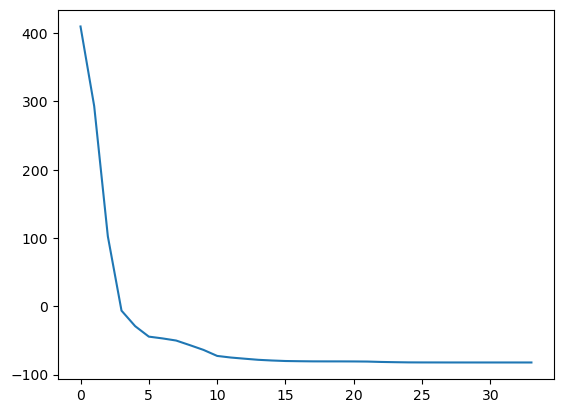

╒════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════╕
│ name                                               │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                   │
╞════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════╡
│ ConditionalMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.2160552511849213      │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────┤
│ ConditionalMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.016713089274316688    │
├────────────────────────────────────────────────────┼──────────

In [3]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
nIVS = 50
print(X)
ivs = np.linspace(min(X[:,0]), max(X[:,0]), nIVS).reshape(-1, 1)
print(ivs)
iv_ind = np.concatenate((np.ones((int(nIVS/2),1 )), np.zeros((int(nIVS/2), 1))))  # I guess the IPs for the target don't matter here, but this makes the comparison fair.
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg
model1 = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#m = SparseCMOGP((X, y), exact_target=False, kernel=kern, jitter=1e-6, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True)
#gpf.set_trainable(m.likelihood.source.variance, False)

gpf.utilities.print_summary(model1)
optimize(model1)
gpf.utilities.print_summary(model1)

TensorShape([3288, 2742])
TensorShape([3288, 2742])
TensorShape([3288, 183])


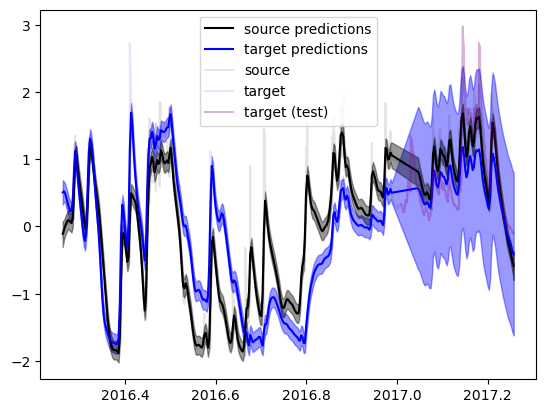

0.2411220644326632

In [4]:
from sklearn.metrics import mean_squared_error
Xtst = Xtest.reshape(-1, 1)
Xall = Ax
Xplot = np.hstack((Xall, np.zeros_like(Xall)))
Xplot2 = np.hstack((Xall, np.ones_like(Xall)))
Xtest_stack = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = model1.predict_f(Xplot)
fmean2, fvar2 = model1.predict_f(Xplot2)
fmean_tst, fvar_tst = model1.predict_f(Xtest_stack)
plt.plot(Xall, fmean, color="k", label="source predictions")
plt.plot(Xall, fmean2, color="b", label="target predictions")
plt.plot(Ax, Ay, "k", alpha=0.1, label="source")
plt.plot(Bx, By, "b", alpha=0.1, label="target")
plt.plot(Xtest, ytest, "purple", alpha=0.3, label="target (test)")
plt.fill_between(
    Xall[:, 0],
    (fmean2 - 2 * np.sqrt(fvar2))[:, 0],
    (fmean2 + 2 * np.sqrt(fvar2))[:, 0],
    color="b",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="k",
    alpha=0.4,
)
plt.legend()
#plt.scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs[:,0])*0, marker="x", c=ivs[:,1], zorder=100, s=100, alpha=0.6)
plt.show()
ours_mse = mean_squared_error(ytest, fmean_tst)
ours_mse

[[2.01626283e+03 0.00000000e+00]
 [2.01626283e+03 0.00000000e+00]
 [2.01626283e+03 0.00000000e+00]
 ...
 [2.01700274e+03 1.00000000e+00]
 [2.01700548e+03 1.00000000e+00]
 [2.01700548e+03 1.00000000e+00]]
[2016.26283368] [2017.25735797]
<Parameter: name=identity, dtype=float64, shape=[100, 2], fn="identity", numpy=
array([[2.01665462e+03, 1.00000000e+00],
       [2.01639343e+03, 1.00000000e+00],
       [2.01641352e+03, 1.00000000e+00],
       [2.01638338e+03, 1.00000000e+00],
       [2.01677516e+03, 1.00000000e+00],
       [2.01708658e+03, 1.00000000e+00],
       [2.01651398e+03, 1.00000000e+00],
       [2.01666466e+03, 1.00000000e+00],
       [2.01647379e+03, 1.00000000e+00],
       [2.01720713e+03, 1.00000000e+00],
       [2.01718704e+03, 1.00000000e+00],
       [2.01645370e+03, 1.00000000e+00],
       [2.01703635e+03, 1.00000000e+00],
       [2.01661443e+03, 1.00000000e+00],
       [2.01709663e+03, 1.00000000e+00],
       [2.01634320e+03, 1.00000000e+00],
       [2.01643361e+03, 1.00

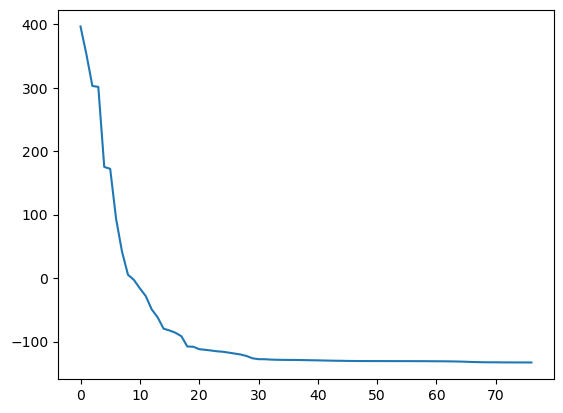

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤═════════════════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value                               │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪═════════════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 1.65854                             │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼─────────────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 0.10343223030833634                 │
├─────────

In [5]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf
from robust_svgp import LMCInducingVariable

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
nIVS = 100
print(X)
ivs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), nIVS).reshape(-1, 1)
print(ivs[0], ivs[-1])
iv_ind = np.concatenate((np.ones((int(nIVS/2),1 )), np.zeros((int(nIVS/2), 1))))  # I guess the IPs for the target don't matter here, but this makes the comparison fair.
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg
#m = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
model2 = SparseCMOGP((X, y), exact_target=False, kernel=kern, jitter=1e-5, inducing_variable=LMCInducingVariable(ivs), likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True)
#gpf.set_trainable(m.likelihood.source.variance, False)
print(model2.inducing_variable.Z)

gpf.utilities.print_summary(model2)
optimize(model2)
gpf.utilities.print_summary(model2)
print(model2.inducing_variable.Z)

[[0.5312196 ]
 [0.5312196 ]
 [0.66938035]
 [0.66938035]
 [0.79677672]
 [0.79677672]
 [0.9149857 ]
 [0.9149857 ]
 [1.02764019]
 [1.02764019]
 [1.13991473]
 [1.13991473]
 [1.2575386 ]
 [1.2575386 ]
 [1.38353678]
 [1.38353678]
 [1.51922099]
 [1.51922099]
 [1.66551984]
 [1.66551984]
 [1.82292075]
 [1.82292075]
 [1.99071372]
 [1.99071372]
 [2.16326975]
 [2.16326975]
 [2.33439606]
 [2.33439606]
 [2.49955148]
 [2.49955148]
 [2.65579163]
 [2.65579163]
 [2.80198384]
 [2.80198384]
 [2.93726528]
 [2.93726528]
 [3.06054341]
 [3.06054341]
 [3.17146519]
 [3.17146519]
 [3.27166941]
 [3.27166941]
 [3.36395982]
 [3.36395982]
 [3.45136683]
 [3.45136683]
 [3.53426231]
 [3.53426231]
 [3.61247408]
 [3.61247408]
 [3.68776138]
 [3.68776138]
 [3.76197063]
 [3.76197063]
 [3.83447258]
 [3.83447258]
 [3.90339055]
 [3.90339055]
 [3.96580451]
 [3.96580451]
 [4.01928307]
 [4.01928307]
 [4.06413295]
 [4.06413295]
 [4.10261346]
 [4.10261346]
 [4.1380883 ]
 [4.1380883 ]
 [4.17169012]
 [4.17169012]
 [4.20332677]
 [4.20

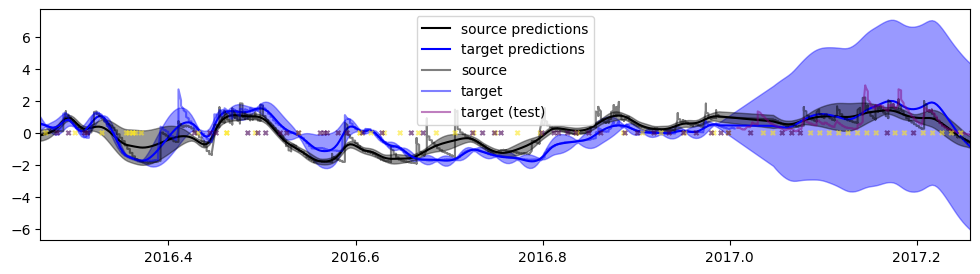

0.253427954086824

In [6]:
from sklearn.metrics import mean_squared_error
Xtst = Xtest.reshape(-1, 1)
Xall = Ax
Xplot = np.hstack((Xall, np.zeros_like(Xall)))
Xplot2 = np.hstack((Xall, np.ones_like(Xall)))
Xtest_stack = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = model2.predict_f(Xplot)
fmean2, fvar2 = model2.predict_f(Xplot2)
fmean_tst, fvar_tst = model2.predict_f(Xtest_stack)
print(2*np.sqrt(fvar_tst))
plt.figure(figsize=(12, 3))
plt.plot(Xall, fmean, color="k", label="source predictions")
plt.plot(Xall, fmean2, color="b", label="target predictions")
plt.plot(Ax, Ay, "k", alpha=0.5, label="source")
plt.plot(Bx, By, "b", alpha=0.5, label="target")
plt.plot(Xtest, ytest, "purple", alpha=0.5, label="target (test)")
plt.fill_between(
    Xall[:, 0],
    (fmean2 - 2 * np.sqrt(fvar2))[:, 0],
    (fmean2 + 2 * np.sqrt(fvar2))[:, 0],
    color="b",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="k",
    alpha=0.4,
)
plt.legend()
plt.scatter(model2.inducing_variable.Z[:,0], 3*np.ones_like(ivs[:,0])*0, marker="x", c=ivs[:,1], zorder=100, s=10, alpha=0.6)
plt.xlim(np.min(X[:,0]), np.max(X[:,0]))
plt.show()
ours_mse = mean_squared_error(ytest, fmean_tst)
ours_mse

In [7]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
from robust_svgp import LMCInducingPointsBase
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32()

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

lik = TransferLikelihood(
    source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()
)

nIVS = 100
print(X)
ivs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), nIVS).reshape(-1, 1)
print(ivs[0], ivs[-1])
iv_ind = np.concatenate((np.ones((int(nIVS/2),1 )), np.zeros((int(nIVS/2), 1))))  # I guess the IPs for the target don't matter here, but this makes the comparison fair.
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
# now build the GP model as normal
model3 = gpf.models.SVGP(kernel=kern, likelihood=lik, num_data=len(X), inducing_variable=LMCInducingPointsBase(ivs))

# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    model3.training_loss_closure((X, y)),
    model3.trainable_variables,
    method="L-BFGS-B",
)

gpf.utilities.print_summary(model3)

[[2.01626283e+03 0.00000000e+00]
 [2.01626283e+03 0.00000000e+00]
 [2.01626283e+03 0.00000000e+00]
 ...
 [2.01700274e+03 1.00000000e+00]
 [2.01700548e+03 1.00000000e+00]
 [2.01700548e+03 1.00000000e+00]]
[2016.26283368] [2017.25735797]


2026-08-25 15:18:26.515173: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-08-25 15:18:26.555212: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═══════════════╤═════════╤═══════════════════════════════════════════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape         │ dtype   │ value                                                 │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═══════════════╪═════════╪═══════════════════════════════════════════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()            │ float64 │ 1.08905                                               │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼───────────────┼─────────┼───────────────────────────────────────────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True      

TensorShape([3288, 2742])
TensorShape([3288, 2742])
TensorShape([3288, 183])


ValueError: 'bottomright' is not a valid value for loc; supported values are 'best', 'upper right', 'upper left', 'lower left', 'lower right', 'right', 'center left', 'center right', 'lower center', 'upper center', 'center'

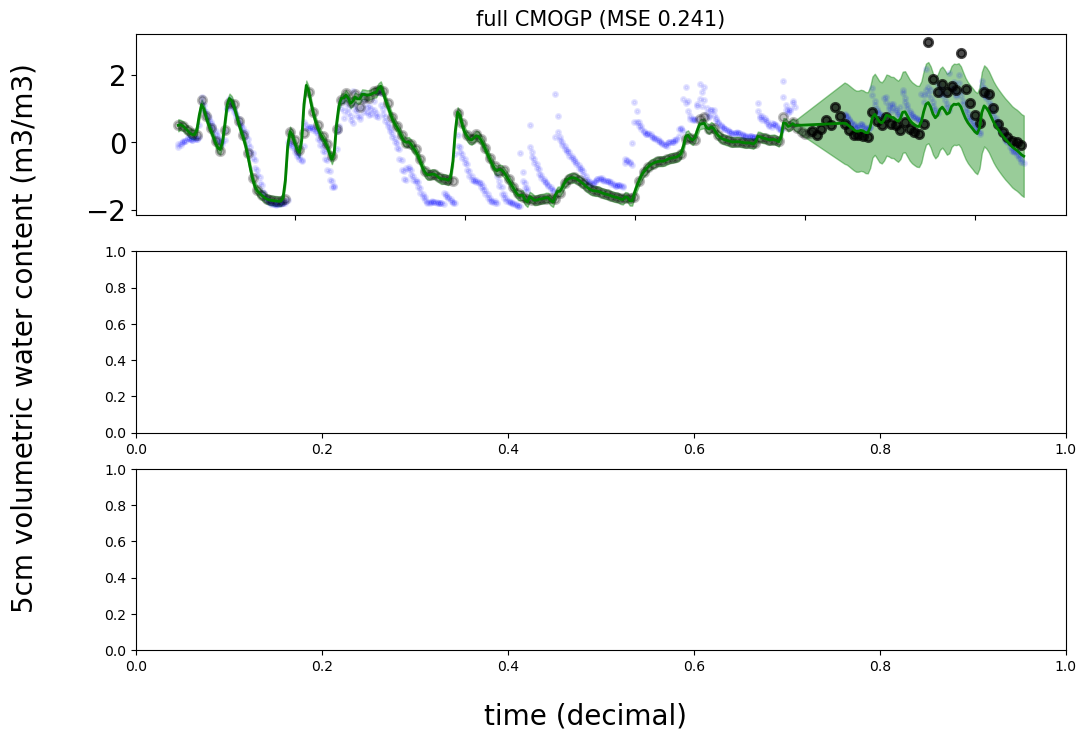

In [85]:
from sklearn.metrics import mean_squared_error

colors = ["green", "darkmagenta", "darkcyan"]
fig, ax = plt.subplots(3, 1, figsize=(12, 8))
for i ,(name, m) in enumerate(zip(["full CMOGP", "sparse CMOGP", "sparse VGP"], [model1, model2, model3])):
    Xtst = Xtest.reshape(-1, 1)
    Xall = Ax
    Xplot = np.hstack((Xall, np.zeros_like(Xall)))
    Xplot2 = np.hstack((Xall, np.ones_like(Xall)))
    Xtest_stack = np.hstack((Xtst, np.ones_like(Xtst)))
    fmean, fvar = m.predict_f(Xplot)
    fmean2, fvar2 = m.predict_f(Xplot2)
    fmean_tst, fvar_tst = m.predict_f(Xtest_stack)
    #ax[i].plot(Xall, fmean, color=colors[i], lw =2, label="source predictions" if i ==0 else "__nolegend__")
    ax[i].plot(Xall, fmean2, color=colors[i], lw=2, zorder=100, label="target predictions")
    ax[i].plot(Ax, Ay, "b.", markevery=4, ms=6, mew=2, alpha=0.1, label="source (25% marked)")
    ax[i].plot(Bx, By, "k.", markevery=4, ms=12, mew=2, alpha=0.25, label="target (25% marked)")
    ax[i].plot(Xtest, ytest, "k.", markevery=4, ms=12, mew=2, alpha=0.7, label="target test (25% marked)")
    fig.supxlabel("time (decimal)", fontsize=20)
    fig.supylabel("5cm volumetric water content (m3/m3)", fontsize=20)
    ours_mse = mean_squared_error(ytest, fmean_tst)
    ax[i].set_title(name + f" (MSE {np.round(ours_mse, 3)})", fontsize=15)
    if i < 2:
        ax[i].set_xticklabels([])
    ax[i].tick_params(axis='both', labelsize=20)
    ax[i].fill_between(
        Xall[:, 0],
        (fmean2 - 2 * np.sqrt(fvar2))[:, 0],
        (fmean2 + 2 * np.sqrt(fvar2))[:, 0],
        color=colors[i],
        alpha=0.4,
    )
    # # ax[i].fill_between(
    # #     Xall[:, 0],
    # #     (fmean - 2 * np.sqrt(fvar))[:, 0],
    # #     (fmean + 2 * np.sqrt(fvar))[:, 0],
    # #     color="k",
    # #     alpha=0.4,
    # )
    ax[i].legend(loc="bottomright")
    if "sparse" in name:
        print(name)
        ax[i].scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs[:,0])*3, marker="|", c=m.inducing_variable.Z[:,1], cmap="BrBG" if i == 2 else "PRGn", zorder=100, s=50, linewidth=3, alpha=0.6, label= "inducing points" if i == 1 else "__nolegend__")
    ax[i].set_xlim(np.min(X[:,0]), np.max(X[:,0]))
    ax[i].set_ylim(-3.1, 3.1)
    plt.tight_layout()
    print("MSE is", ours_mse)

TensorShape([3288, 2742])
TensorShape([3288, 2742])
TensorShape([3288, 183])
MSE is 0.2411220644326632
sparse CMOGP
MSE is 0.253427954086824
sparse VGP
MSE is 1.0030645409587415


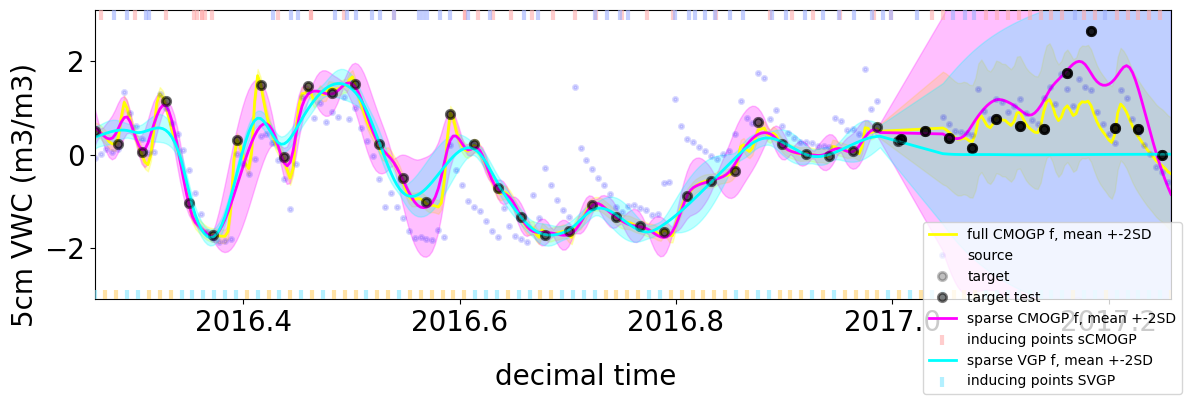

In [76]:
from sklearn.metrics import mean_squared_error

fig, ax = plt.subplots(1, 1, figsize=(12, 4))

colors = ["yellow", "magenta", "cyan"]
for i ,(name, m) in enumerate(zip(["full CMOGP", "sparse CMOGP", "sparse VGP"], [model1, model2, model3])):
    Xtst = Xtest.reshape(-1, 1)
    Xall = Ax
    Xplot = np.hstack((Xall, np.zeros_like(Xall)))
    Xplot2 = np.hstack((Xall, np.ones_like(Xall)))
    Xtest_stack = np.hstack((Xtst, np.ones_like(Xtst)))
    fmean, fvar = m.predict_f(Xplot)
    fmean2, fvar2 = m.predict_f(Xplot2)
    fmean_tst, fvar_tst = m.predict_f(Xtest_stack)
    #ax[0].plot(Xall, fmean, color="k", lw =2, label="source predictions" if i ==0 else "__nolegend__")
    ax.plot(Xall, fmean2, color=colors[i], lw=2, label=f"{name} f, mean +-2SD")
    ax.plot(Ax, Ay, "b.", markevery=16, ms=6, mew=2, alpha=0.05, label="source" if i == 0 else "__nolegend__")
    ax.plot(Bx, By, "k.", markevery=16, ms=12, mew=2, alpha=0.25, label="target" if i == 0 else "__nolegend__")
    ax.plot(Xtest, ytest, "k.", markevery=16, ms=12, mew=2, alpha=0.5, label="target test" if i == 0 else "__nolegend__")
    fig.supxlabel("decimal time", fontsize=20)
    fig.supylabel("5cm VWC (m3/m3)", fontsize=20)
    ours_mse = mean_squared_error(ytest, fmean_tst)
    #ax.set_title(name + f"(MSE {np.round(ours_mse, 3)})", fontsize=15)
    if i < -1:
        ax.set_xticklabels([])
    ax.tick_params(axis='both', labelsize=20)
    ax.fill_between(
        Xall[:, 0],
        (fmean2 - 2 * np.sqrt(fvar2))[:, 0],
        (fmean2 + 2 * np.sqrt(fvar2))[:, 0],
        color=colors[i],
        alpha=0.25,
    )
    if "sparse" in name:
        print(name)
        ax.scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs[:,0])*3 if i == 1 else np.ones_like(ivs[:,0]) * -3, marker="|", c=m.inducing_variable.Z[:,1], cmap="berlin" if i == 1 else "managua",  zorder=100, s=50, linewidth=3, alpha=0.6, label= "inducing points sCMOGP" if i == 1 else "inducing points SVGP")
    ax.set_xlim(np.min(X[:,0]), np.max(X[:,0]))
    ax.set_ylim(-3.1, 3.1)
    print("MSE is", ours_mse)

fig.legend(loc="lower right", ncol=1)
plt.tight_layout()